In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [14]:
df = pd.read_csv("data_banknote_authentication.txt")

column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]
df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_names
)
print(df.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [15]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1372, 5)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [17]:
print(df.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [18]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


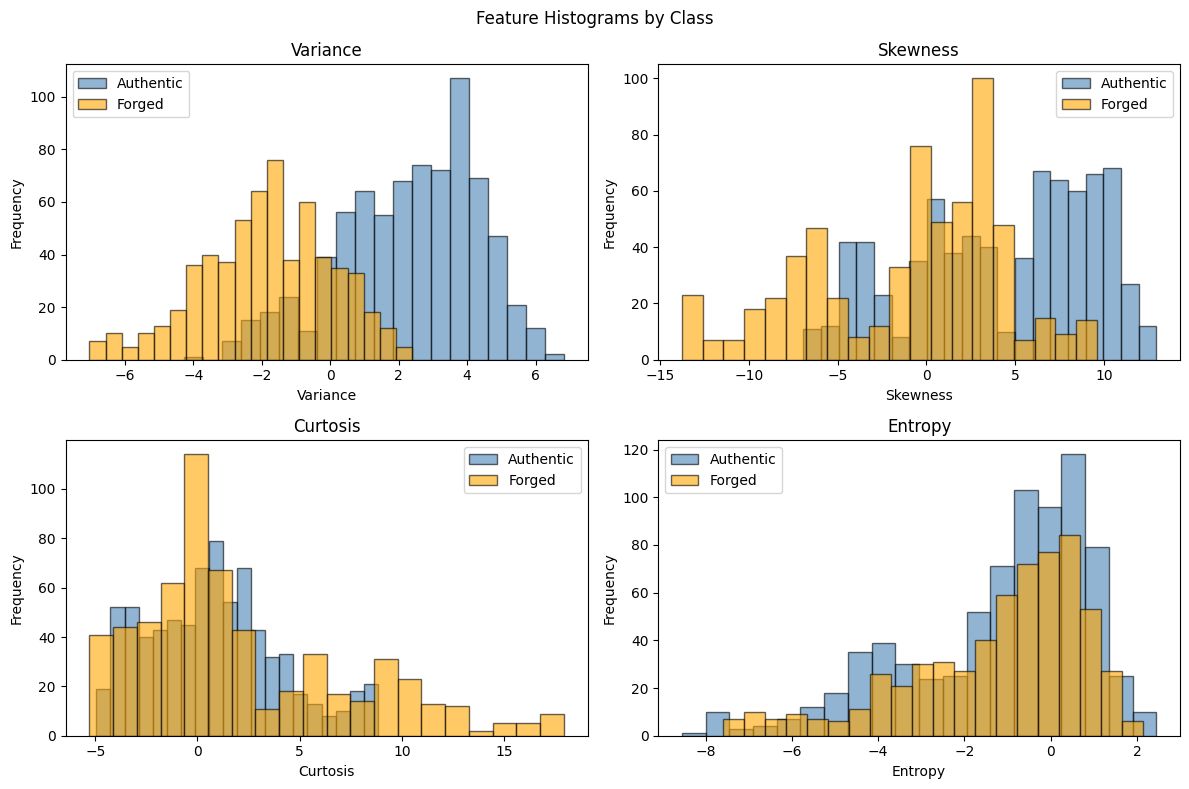

In [55]:
#2.EDA
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
feature_names = df.columns[:-1]

for ax, feature in zip(axes.ravel(), feature_names):
    ax.hist(
        df[df["Class"] == 0][feature],
        bins=20,
        color="steelblue",
        edgecolor="black",
        alpha=0.6,
        label="Authentic"
    )

    ax.hist(
        df[df["Class"] == 1][feature],
        bins=20,
        color="orange",
        edgecolor="black",
        alpha=0.6,
        label="Forged"
    )

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Feature Histograms by Class")
plt.tight_layout()

plt.savefig(
    "feature_histograms.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "feature_histograms.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

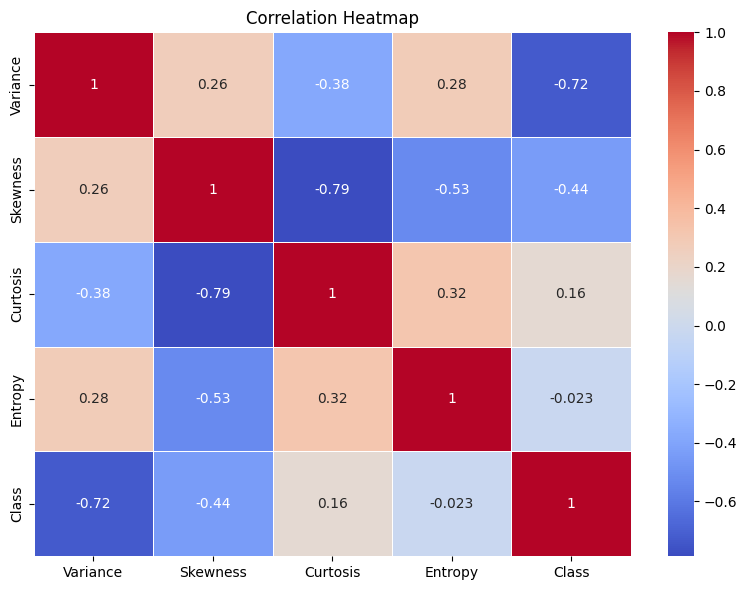

In [21]:
plt.figure(figsize=(8,6))
correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

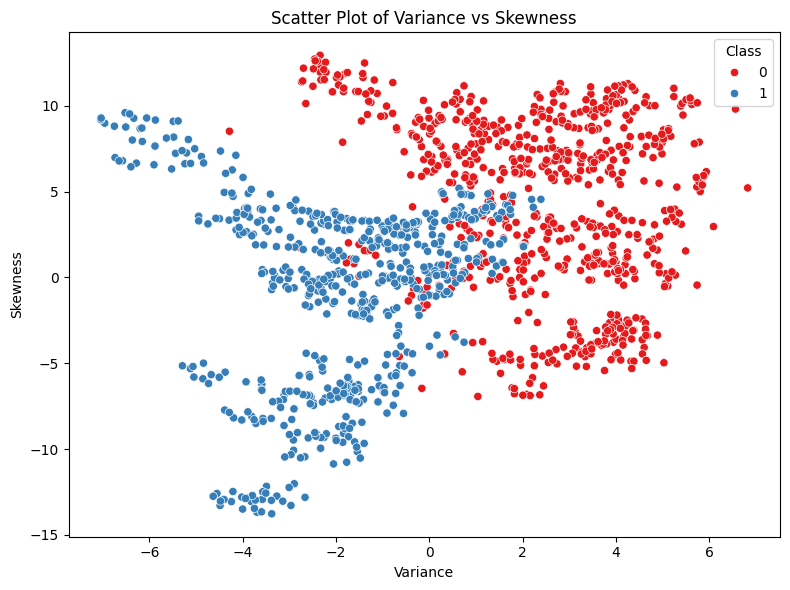

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Variance',
    y='Skewness',
    hue='Class',
    palette='Set1'
)

plt.title("Scatter Plot of Variance vs Skewness")

plt.xlabel("Variance")
plt.ylabel("Skewness")

plt.tight_layout()

plt.savefig(
    "scatter_variance_skewness.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

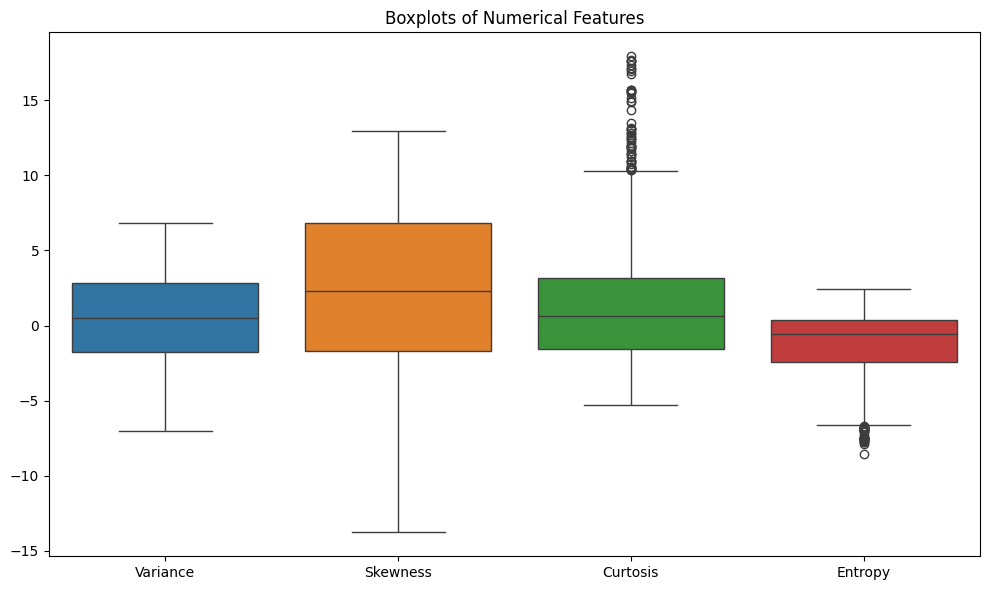

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.iloc[:, :-1])

plt.title("Boxplots of Numerical Features")

plt.tight_layout()

plt.savefig(
    "boxplots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [25]:
#3. Data Preprocessing
# Input features
X = df.iloc[:, :-1]
# Target variable
y = df.iloc[:, -1]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [28]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)


Training Set: (1097, 4)
Testing Set: (275, 4)
Training Labels: (1097,)
Testing Labels: (275,)


In [29]:
class SingleLayerPerceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.errors = []
        self.weight_history = []
        self.bias_history = []

        self.best_weights = None
        self.best_bias = None
        self.best_error = float('inf')

    def step_activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    def predict_single(self, x):
        z = np.dot(x, self.weights) + self.bias
        output = self.step_activation(z)
        return output

    def fit(self, X_train, y_train):
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0
            for x, y in zip(X_train, y_train):
                y_pred = self.predict_single(x)

                update = self.learning_rate * (y - y_pred)
                self.weights = self.weights + update * x

                self.bias = self.bias + update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

            self.weight_history.append(
                self.weights.copy()
            )

            self.bias_history.append(
                self.bias
            )

            if errors < self.best_error:
                self.best_error = errors
                self.best_weights = self.weights.copy()
                self.best_bias = self.bias

            print("Epoch:", epoch+1)
            print("Misclassified Samples:", errors)
            print("Updated Weights:", self.weights)
            print("Updated Bias:", self.bias)
            print("----------------------------")

        self.weights = self.best_weights
        self.bias = self.best_bias


    def predict(self, X):
        predictions=[]
        for x in X:
            predictions.append(self.predict_single(x))
        return np.array(predictions)

In [30]:
#5. Model Training
perceptron = SingleLayerPerceptron(
    learning_rate=0.01,
    epochs=50
)

perceptron.fit(
    X_train,
    y_train.values
)

Epoch: 1
Misclassified Samples: 168
Updated Weights: [-0.07006804 -0.04079083 -0.05334423  0.02214898]
Updated Bias: 0.08
----------------------------
Epoch: 2
Misclassified Samples: 82
Updated Weights: [-0.08719187 -0.05646195 -0.0754296   0.01040463]
Updated Bias: 0.09999999999999999
----------------------------
Epoch: 3
Misclassified Samples: 65
Updated Weights: [-0.09159189 -0.06921483 -0.09301243  0.01238352]
Updated Bias: 0.10999999999999999
----------------------------
Epoch: 4
Misclassified Samples: 49
Updated Weights: [-0.09454715 -0.08195606 -0.09688747  0.01167393]
Updated Bias: 0.11999999999999998
----------------------------
Epoch: 5
Misclassified Samples: 41
Updated Weights: [-0.09744663 -0.08880488 -0.09760507  0.00707786]
Updated Bias: 0.12999999999999998
----------------------------
Epoch: 6
Misclassified Samples: 51
Updated Weights: [-0.10542831 -0.098205   -0.09948946  0.00500618]
Updated Bias: 0.13999999999999999
----------------------------
Epoch: 7
Misclassified S

In [31]:
#6. Model Evaluation
y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9854545454545455
Precision: 1.0
Recall   : 0.968503937007874
F1 Score : 0.984

Confusion Matrix:
[[148   0]
 [  4 123]]


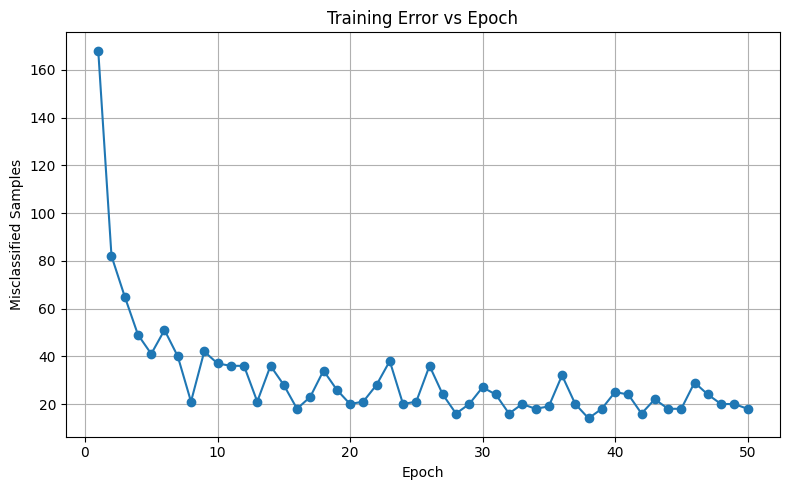

In [32]:
#7. Plots
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(perceptron.errors)+1),
    perceptron.errors,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid()
plt.tight_layout()

plt.savefig(
    "training_error.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

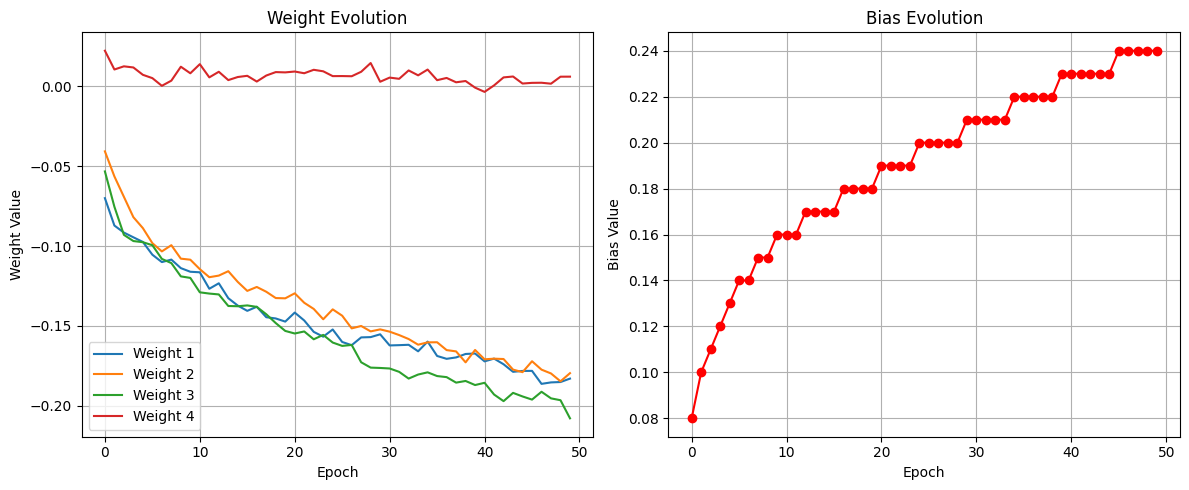

In [33]:
weights = np.array(perceptron.weight_history)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(weights[:,0], label="Weight 1")
plt.plot(weights[:,1], label="Weight 2")
plt.plot(weights[:,2], label="Weight 3")
plt.plot(weights[:,3], label="Weight 4")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")
plt.legend()
plt.grid()


plt.subplot(1,2,2)
plt.plot(perceptron.bias_history, color='red', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution")
plt.grid()


plt.tight_layout()

plt.savefig(
    "weight_bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

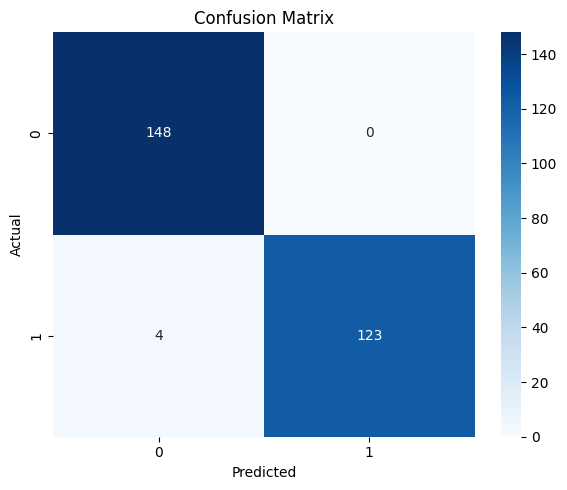

In [34]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [35]:
learning_rates = [0.001, 0.01, 0.1]
training_errors = {}

for lr in learning_rates:
    model = SingleLayerPerceptron(
        learning_rate=lr,
        epochs=50
    )

    model.fit(
        X_train,
        y_train.values
    )
    training_errors[lr] = model.errors

Epoch: 1
Misclassified Samples: 168
Updated Weights: [-0.0070068  -0.00407908 -0.00533442  0.0022149 ]
Updated Bias: 0.008
----------------------------
Epoch: 2
Misclassified Samples: 82
Updated Weights: [-0.00871919 -0.0056462  -0.00754296  0.00104046]
Updated Bias: 0.010000000000000002
----------------------------
Epoch: 3
Misclassified Samples: 65
Updated Weights: [-0.00915919 -0.00692148 -0.00930124  0.00123835]
Updated Bias: 0.011000000000000003
----------------------------
Epoch: 4
Misclassified Samples: 49
Updated Weights: [-0.00945472 -0.00819561 -0.00968875  0.00116739]
Updated Bias: 0.012000000000000004
----------------------------
Epoch: 5
Misclassified Samples: 41
Updated Weights: [-0.00974466 -0.00888049 -0.00976051  0.00070779]
Updated Bias: 0.013000000000000005
----------------------------
Epoch: 6
Misclassified Samples: 51
Updated Weights: [-0.01054283 -0.0098205  -0.00994895  0.00050062]
Updated Bias: 0.014000000000000005
----------------------------
Epoch: 7
Misclassi

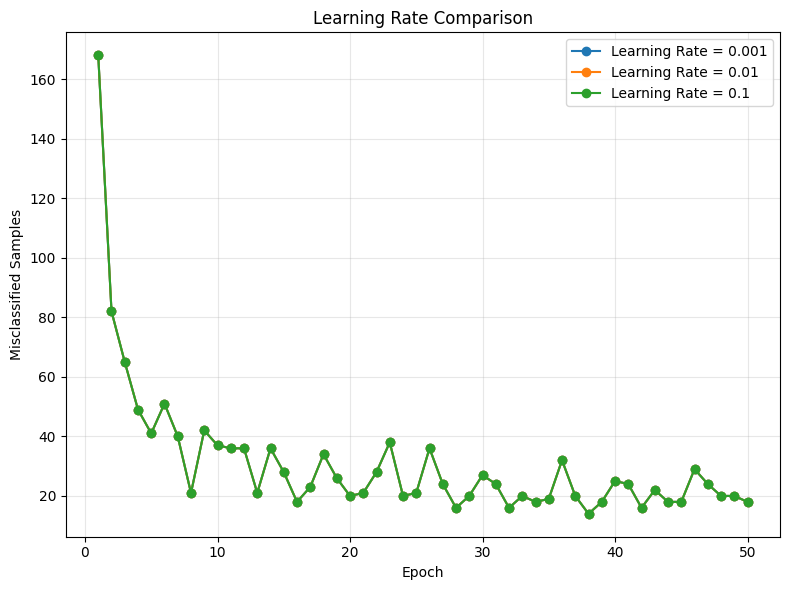

In [36]:
plt.figure(figsize=(8,6))

for lr in learning_rates:

    plt.plot(
        range(1, len(training_errors[lr]) + 1),
        training_errors[lr],
        marker='o',
        label=f"Learning Rate = {lr}"
    )

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "learning_rate_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [37]:
#8. Comparing implementation with scikit's perceptron
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sk_model = Perceptron(
    max_iter=50,
    eta0=0.01,
    random_state=42,
    tol=None
)

sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)

sk_accuracy = accuracy_score(y_test, sk_pred)
sk_precision = precision_score(y_test, sk_pred)
sk_recall = recall_score(y_test, sk_pred)
sk_f1 = f1_score(y_test, sk_pred)

print("\nMy Perceptron Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nScikit-learn Perceptron Results")
print("----------------------------")
print("Accuracy :", sk_accuracy)
print("Precision:", sk_precision)
print("Recall   :", sk_recall)
print("F1 Score :", sk_f1)


print("\nLearned Parameters")
print("---------------------------")

print("My Model Weights      :", perceptron.weights)
print("Scikit-learn Weights  :", sk_model.coef_[0])

print("\nMy Model Bias         :", perceptron.bias)
print("Scikit-learn Bias     :", sk_model.intercept_[0])


My Perceptron Results
----------------------------
Accuracy : 0.9854545454545455
Precision: 1.0
Recall   : 0.968503937007874
F1 Score : 0.984

Scikit-learn Perceptron Results
----------------------------
Accuracy : 0.9745454545454545
Precision: 1.0
Recall   : 0.9448818897637795
F1 Score : 0.97165991902834

Learned Parameters
---------------------------
My Model Weights      : [-0.16966474 -0.16589198 -0.18542884  0.00239884]
Scikit-learn Weights  : [-0.19322088 -0.1965121  -0.20103524  0.00392586]

My Model Bias         : 0.22000000000000006
Scikit-learn Bias     : 0.25000000000000006


In [38]:
import sklearn
print(sklearn.__version__)

1.6.1


In [51]:
#9. Decision Boundary using Variance and Skewness

X_db = df[["Variance", "Skewness"]]
y_db = df["Class"]

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db,
    y_db,
    test_size=0.2,
    random_state=42,
    stratify=y_db
)

scaler_db = MinMaxScaler()

X_train_db = scaler_db.fit_transform(X_train_db)
X_test_db = scaler_db.transform(X_test_db)

In [52]:
boundary_model = SingleLayerPerceptron(
    learning_rate=0.01,
    epochs=50
)

boundary_model.fit(
    X_train_db,
    y_train_db.values
)

Epoch: 1
Misclassified Samples: 247
Updated Weights: [-0.06425077 -0.04360273]
Updated Bias: 0.05
----------------------------
Epoch: 2
Misclassified Samples: 187
Updated Weights: [-0.07514512 -0.0426944 ]
Updated Bias: 0.060000000000000005
----------------------------
Epoch: 3
Misclassified Samples: 200
Updated Weights: [-0.07861356 -0.044754  ]
Updated Bias: 0.060000000000000005
----------------------------
Epoch: 4
Misclassified Samples: 183
Updated Weights: [-0.08194881 -0.04566531]
Updated Bias: 0.07
----------------------------
Epoch: 5
Misclassified Samples: 180
Updated Weights: [-0.07722296 -0.04665331]
Updated Bias: 0.07
----------------------------
Epoch: 6
Misclassified Samples: 189
Updated Weights: [-0.07843293 -0.04493673]
Updated Bias: 0.060000000000000005
----------------------------
Epoch: 7
Misclassified Samples: 185
Updated Weights: [-0.0848141  -0.04344929]
Updated Bias: 0.07
----------------------------
Epoch: 8
Misclassified Samples: 178
Updated Weights: [-0.078229

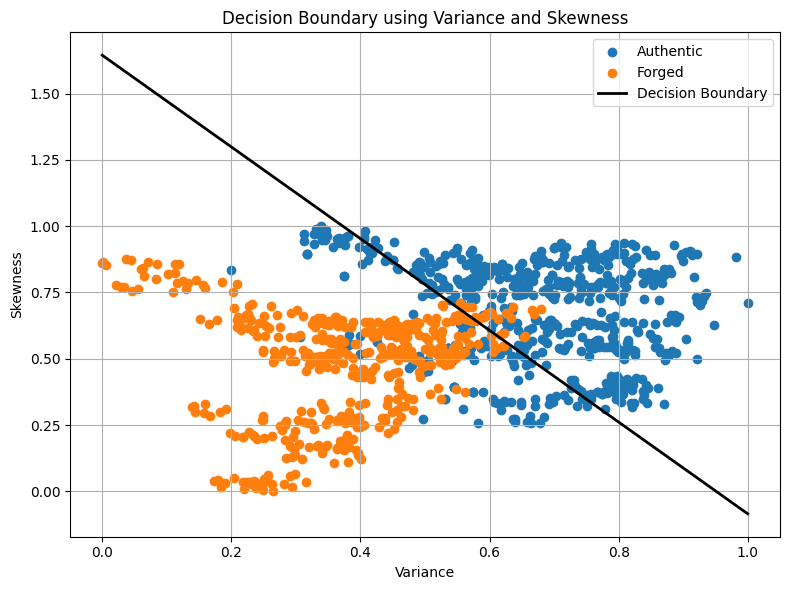

In [56]:
plt.figure(figsize=(8,6))

# Plot training samples
plt.scatter(
    X_train_db[y_train_db.values == 0, 0],
    X_train_db[y_train_db.values == 0, 1],
    label="Authentic"
)

plt.scatter(
    X_train_db[y_train_db.values == 1, 0],
    X_train_db[y_train_db.values == 1, 1],
    label="Forged"
)

# Decision Boundary
w = boundary_model.weights
b = boundary_model.bias

x = np.linspace(
    X_train_db[:,0].min(),
    X_train_db[:,0].max(),
    100
)

y = -(w[0]*x + b)/w[1]

plt.plot(
    x,
    y,
    color="black",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Decision Boundary using Variance and Skewness")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "decision_boundary.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()